# MES Support/Resistance + Psychological Level Breakout, Tradovate exchange

Same event-driven engine, data source, and cost model as the other notebooks in
this repo (Databento `MES.c.0` 1-minute Parquet resampled locally, whole-contract
sizing, real tick slippage + per-contract commission, Tradeify-style middleware).

**Strategy idea**: rather than a fixed session range (ORB) or a volatility
squeeze (Bollinger/VWAP), this pass builds a rolling map of *horizontal*
support/resistance levels from two combined signal sources, and trades the break
of the nearest one:

1. **Empirical levels** -- a "time at price" histogram
   (`Indicators.support_resistance_levels`, new this pass): over a trailing
   window of 5-minute closes, bucket price into `bin_size`-wide bins and count how
   many bars fell in each. A bin that's both a local peak and crossed a minimum
   touch count is a "high-dwell node" -- price consolidated there rather than
   crossing straight through, the classic definition of chart support/resistance.
2. **Psychological levels** -- a static round-number grid (every 25 points for
   MES/ES, the standard convention for index futures; 100-point marks fall out of
   this for free since 100 is a multiple of 25) spanning the window's price range.

Both are computed on **5-minute** bars (finer granularity resolves the histogram
better and catches more round-number touches), recomputed once per trading day
(not every bar -- levels don't need per-bar freshness, and it's far cheaper), then
reindexed onto the **1-hour** bars the strategy actually trades on. The reindex is
an exact-timestamp match for >99% of hours (a 1h bar's close always coincides with
a 5m bar's close), forward-filled for the rare edge-of-session hour that doesn't.

**Entry** (`backtester.strategies.SupportResistanceBreakoutStrategy`, new this
pass): an intrabar stop-order fill, same style as the ORB strategy -- the bar's
high touching the nearest resistance level -> long at max(resistance, open); the
bar's low touching the nearest support level -> short at min(support, open). A bar
touching both in the same hour is skipped (bar-interior ordering is unknowable
from OHLC). **Stop-loss** sits `stop_buffer` points back inside the broken level
(not on the level itself -- a no-gap fill would make entry and stop the same
price). **Take-profit** is fixed at 2x that stop distance (the requested 1:2
risk:reward), so both R:R and the overall structure are exactly what was asked
for; the grid below explores lookback window and stop_buffer, not R:R.

**Known simplifications, stated up front**: (1) entries fire on any intrabar
touch, with no close-confirmation filter -- a real level "breakout" arguably
needs the bar to *close* past the level, not just wick through it; this pass
tests the literal ask (touch-and-go) first. (2) the histogram counts a bar's
*close* only, not its full high-low range, so a level a bar wicks through without
closing near doesn't add a "touch" -- a coarser proxy for dwell time than a true
volume profile. (3) `stop_buffer` is a flat, instrument-scaled constant, not
ATR-scaled -- unlike the ORB notebook's ATR-mode stop, so it doesn't adapt to
changing volatility across the 7-year window.


In [1]:
import datetime as dt
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import StrategyDirection, SupportResistanceBreakoutStrategy
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    # Different notebook runners launch the kernel with different cwds -- walk upward
    # until the target exists instead of assuming a fixed number of parent hops.
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MES"
SYMBOL = "MES/USD"
LEVEL_INTERVAL = 5
LEVEL_UNIT_OF_TIME = "minute"
TRADE_INTERVAL = 60
TRADE_UNIT_OF_TIME = "minute"

mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
ohlc_5m = load_1m_parquet_resampled(mes_path, interval=LEVEL_INTERVAL, unit_of_time=LEVEL_UNIT_OF_TIME)
ohlc_1h = load_1m_parquet_resampled(mes_path, interval=TRADE_INTERVAL, unit_of_time=TRADE_UNIT_OF_TIME)
print(f"5m bars: {len(ohlc_5m)}  span: {ohlc_5m.index[0]} -> {ohlc_5m.index[-1]}")
print(f"1h bars: {len(ohlc_1h)}  span: {ohlc_1h.index[0]} -> {ohlc_1h.index[-1]}")


5m bars: 504547  span: 2019-05-05 22:04:59.999000 -> 2026-07-12 23:09:59.999000
1h bars: 42240  span: 2019-05-05 22:59:59.999000 -> 2026-07-12 23:59:59.999000


## Level indicators: time-at-price histogram + psychological grid, reindexed to 1h

`BIN_SIZE`/`PSYCH_GRID_SIZE`/`RECOMPUTE_EVERY` are fixed instrument-scale
constants (MES: ~1-point bins, 25-point round-number grid, recompute roughly once
per trading day at 5-minute granularity -- ~192 5-minute bars/day averaged across
the 7-year window including weekends/holidays). `min_touches` scales with `window`
(2% of it, floor 5) since a longer lookback naturally accumulates more visits to
any given bin. `window` itself is the parameter the grid below actually varies.


In [3]:
BIN_SIZE = 1.0
PSYCH_GRID_SIZE = 25.0
RECOMPUTE_EVERY = 192  # roughly one trading day of 5-minute bars


def build_level_indicators(window: int) -> tuple[pd.Series, pd.Series]:
    min_touches = max(5, int(window * 0.02))
    support_5m, resistance_5m = Indicators.support_resistance_levels(
        ohlc_5m, window=window, bin_size=BIN_SIZE, min_touches=min_touches,
        recompute_every=RECOMPUTE_EVERY, psych_grid_size=PSYCH_GRID_SIZE,
    )
    # Exact-timestamp reindex: a 1h bar's close always coincides with a 5m bar's
    # close, except at a handful of edge-of-session hours -- ffill covers those.
    support_1h = support_5m.reindex(ohlc_1h.index, method="ffill")
    resistance_1h = resistance_5m.reindex(ohlc_1h.index, method="ffill")
    return support_1h, resistance_1h


# Sanity check: confirm the reindex lines up almost exactly, and print a small
# recent window of levels next to price so they're eyeballable (support below
# close, resistance above, both plausible round/empirical numbers).
_support_1h, _resistance_1h = build_level_indicators(window=1000)
_exact_matches = ohlc_1h.index.isin(
    Indicators.support_resistance_levels(
        ohlc_5m, window=1000, bin_size=BIN_SIZE, min_touches=20,
        recompute_every=RECOMPUTE_EVERY, psych_grid_size=PSYCH_GRID_SIZE,
    )[0].index
).sum()
print(f"1h bars with an exact 5m-close timestamp match: {_exact_matches}/{len(ohlc_1h)}")
_check = pd.DataFrame({
    "close": ohlc_1h["close"], "support": _support_1h, "resistance": _resistance_1h,
}).dropna().tail(8)
print(_check.to_string())
assert (_check["support"] <= _check["close"]).all()
assert (_check["resistance"] > _check["close"]).all()


1h bars with an exact 5m-close timestamp match: 42156/42240
                           close  support  resistance
ts                                                   
2026-07-10 14:59:59.999  7584.00   7582.5      7585.5
2026-07-10 15:59:59.999  7600.50   7600.0      7625.0
2026-07-10 16:59:59.999  7612.50   7600.0      7625.0
2026-07-10 17:59:59.999  7612.50   7600.0      7625.0
2026-07-10 18:59:59.999  7618.75   7600.0      7625.0
2026-07-10 19:59:59.999  7621.00   7600.0      7625.0
2026-07-12 22:59:59.999  7600.75   7600.0      7625.0
2026-07-12 23:59:59.999  7599.75   7586.5      7600.0


## Grid: histogram lookback window x stop-loss buffer

`window` in {1000, 3000} 5-minute bars (~3.6 and ~11 trading days of history) x
`stop_buffer` in {5.0, 10.0, 20.0} MES points. Take-profit is always exactly `2 x
stop_buffer` risk (the requested 1:2 R:R) -- not itself a grid dimension. Fees
tracked from the exchange event log for every combination, same convention as the
other notebooks in this pipeline.


In [4]:
WINDOW_CANDIDATES = [1000, 3000]
STOP_BUFFER_CANDIDATES = [5.0, 10.0, 20.0]
RISK_REWARD_RATIO = 2.0
DEPOSIT_USD = 50_000


def run_sr_backtest(window: int, stop_buffer: float):
    support_1h, resistance_1h = build_level_indicators(window)

    combo_market = Market()
    combo_market.add_market(symbol=SYMBOL, df=ohlc_1h)
    for name, series in [("support", support_1h), ("resistance", resistance_1h)]:
        combo_market.add_indicator(symbol=SYMBOL, interval=TRADE_INTERVAL, unit_of_time=TRADE_UNIT_OF_TIME,
                                    indicator_name=name, df=series)
    combo_market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(
            weight=1.0,
            strategy=SupportResistanceBreakoutStrategy(
                key=f"SR_{window}_{stop_buffer}_MES",
                market=combo_market,
                symbol=SYMBOL,
                resistance_key="resistance",
                support_key="support",
                stop_buffer=stop_buffer,
                risk_reward_ratio=RISK_REWARD_RATIO,
                direction=StrategyDirection.both,
            ),
        ),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=combo_market,
        slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future,
        max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(
        market=combo_market, exchange=exchange, portfolio=portfolio,
        benchmark_symbols=[SYMBOL], periods_per_year=252,
    )

    combo_market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(
        market=combo_market, portfolio=portfolio, exchange=exchange, reporter=reporter,
        middlewares=[daily_loss_middleware, drawdown_middleware],
    )
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


grid_rows = []
grid_backtests = {}
for window in WINDOW_CANDIDATES:
    for stop_buffer in STOP_BUFFER_CANDIDATES:
        _t0 = time.time()
        bt, drawdown_mw = run_sr_backtest(window, stop_buffer)
        print(f"window={window} stop_buffer={stop_buffer} done in {time.time() - _t0:.1f}s", flush=True)
        summary = bt.reporter.summary["algo"]
        total_fees = sum(
            e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled)
        )
        grid_backtests[(window, stop_buffer)] = (bt, drawdown_mw)
        grid_rows.append({
            "window": window,
            "stop_buffer": stop_buffer,
            "gross_return_percent": summary["gross_return_percent"],
            "net_return_percent": summary["net_return_percent"],
            "sharpe_ratio": summary["sharpe_ratio"],
            "max_drawdown_percent": summary["max_drawdown_percent"],
            "closed_trades": summary["closed_trades"],
            "trades_per_year": round(summary["closed_trades"] / 7.2, 1),
            "win_rate_percent": summary["win_rate_percent"],
            "avg_holding_period_min": summary["avg_holding_period_min"],
            "total_fees_usd": total_fees,
            "account_failed": drawdown_mw.account_failed,
        })

grid_results = pd.DataFrame(grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print(grid_results.to_string())


window=1000 stop_buffer=5.0 done in 9.7s


window=1000 stop_buffer=10.0 done in 6.7s


window=1000 stop_buffer=20.0 done in 4.0s


window=3000 stop_buffer=5.0 done in 10.8s


window=3000 stop_buffer=10.0 done in 9.3s


window=3000 stop_buffer=20.0 done in 5.3s


   window  stop_buffer  gross_return_percent  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  avg_holding_period_min  total_fees_usd  account_failed
0    3000         20.0              85.31658           -14.68342     -0.078597              -34.9748         2260.0            313.9         22.787611             1460.469027         5806.71           False
1    1000         20.0              66.12732           -33.87268     -0.309344              -41.4744         1544.0            214.4         24.158031             2241.023316         3616.34           False
2    1000         10.0              65.26762           -34.73238     -0.352487              -46.4670         3275.0            454.9         18.992366              933.453435         6992.44           False
3    3000         10.0              58.14744           -41.85256     -0.595414              -50.3209         2024.0            281.1         15.859684              543.1126

## Detailed report for the best (window, stop_buffer)

Full HTML summary (year-by-year split) and equity/drawdown charts for whichever
combo above ranked best by Sharpe -- same report format as the other notebooks.


Best combo: window=3000, stop_buffer=20.0
Candles Processed: 42239
Account failed (drawdown breach): False
Drawdown floor locked (reached profit buffer): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,-0.0786,-0.2264,-0.2106,-0.7581,0.1023,0.6005,0.5369,0.3085,-1.2540,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,-0.1096,-0.3384,-0.2938,-0.9719,0.1425,0.8404,0.7588,0.4471,-1.7049,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,11.2833,9.3496,21.2287,7.9766,12.5913,5.9459,5.7435,9.1861,7.9027,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,-2.1839,-3.6267,-9.3063,-8.8317,0.7233,5.0528,4.3307,3.5648,-13.8289,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,-0.0624,-0.3617,-0.2925,-0.7220,0.0456,0.9688,0.7714,0.3870,-1.6224,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,-0.4198,-0.2393,-0.2925,-0.7202,0.0455,0.9661,0.7714,0.3859,-0.8835,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-34.9748,-10.0270,-31.8130,-12.2316,-15.8702,-5.2153,-5.6144,-9.2123,-8.5240,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,2303,148,284,345,109,143,66,219,188,719,How long it took to recover the loss. Shorter is better.
ulcer_index,26.5043,5.6437,24.5984,7.5309,7.1332,2.3994,1.5955,4.6962,5.4298,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.9311,-0.8534,-1.4011,-0.8677,-1.2344,-0.5479,-0.6161,-0.6628,-0.8805,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


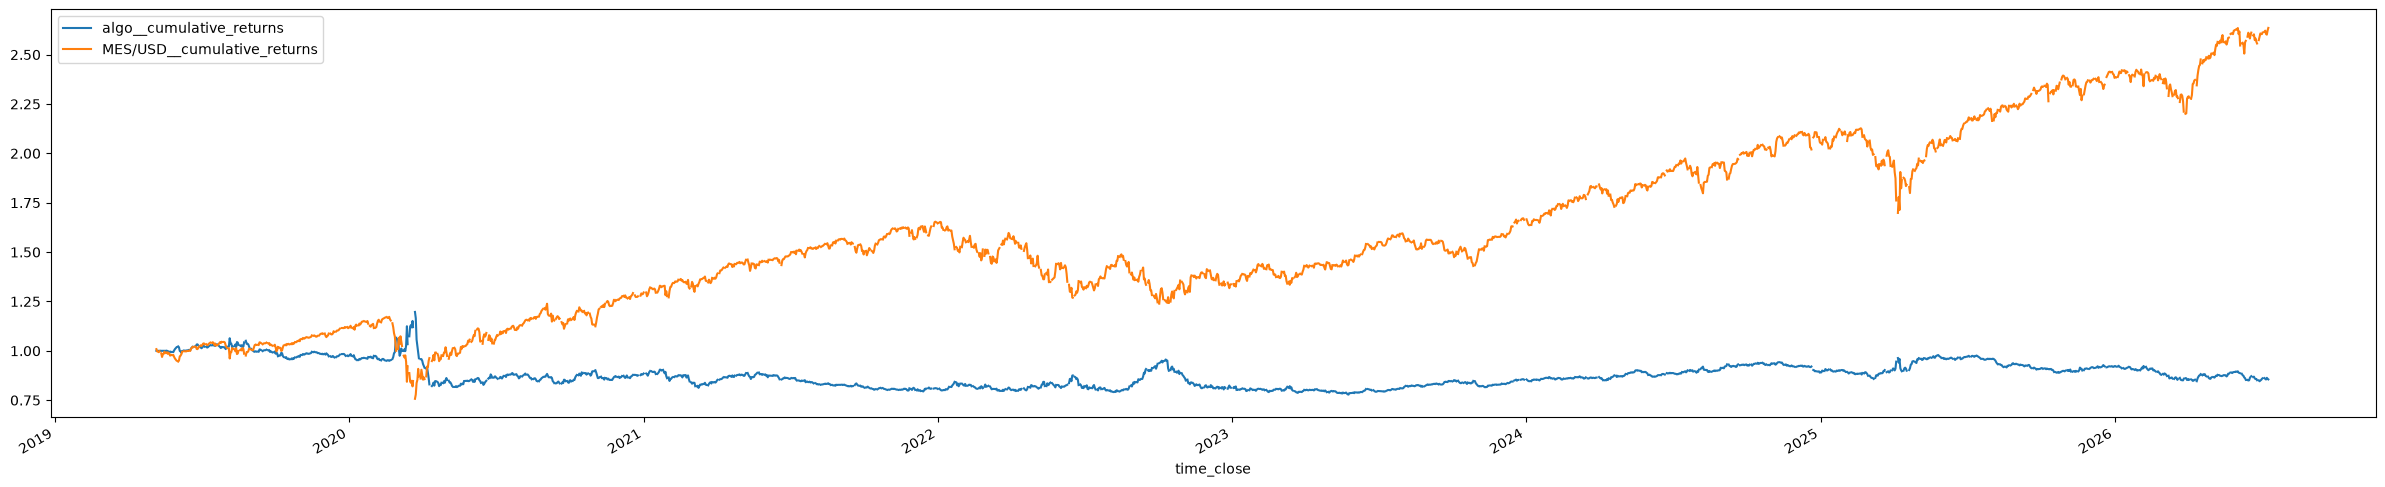

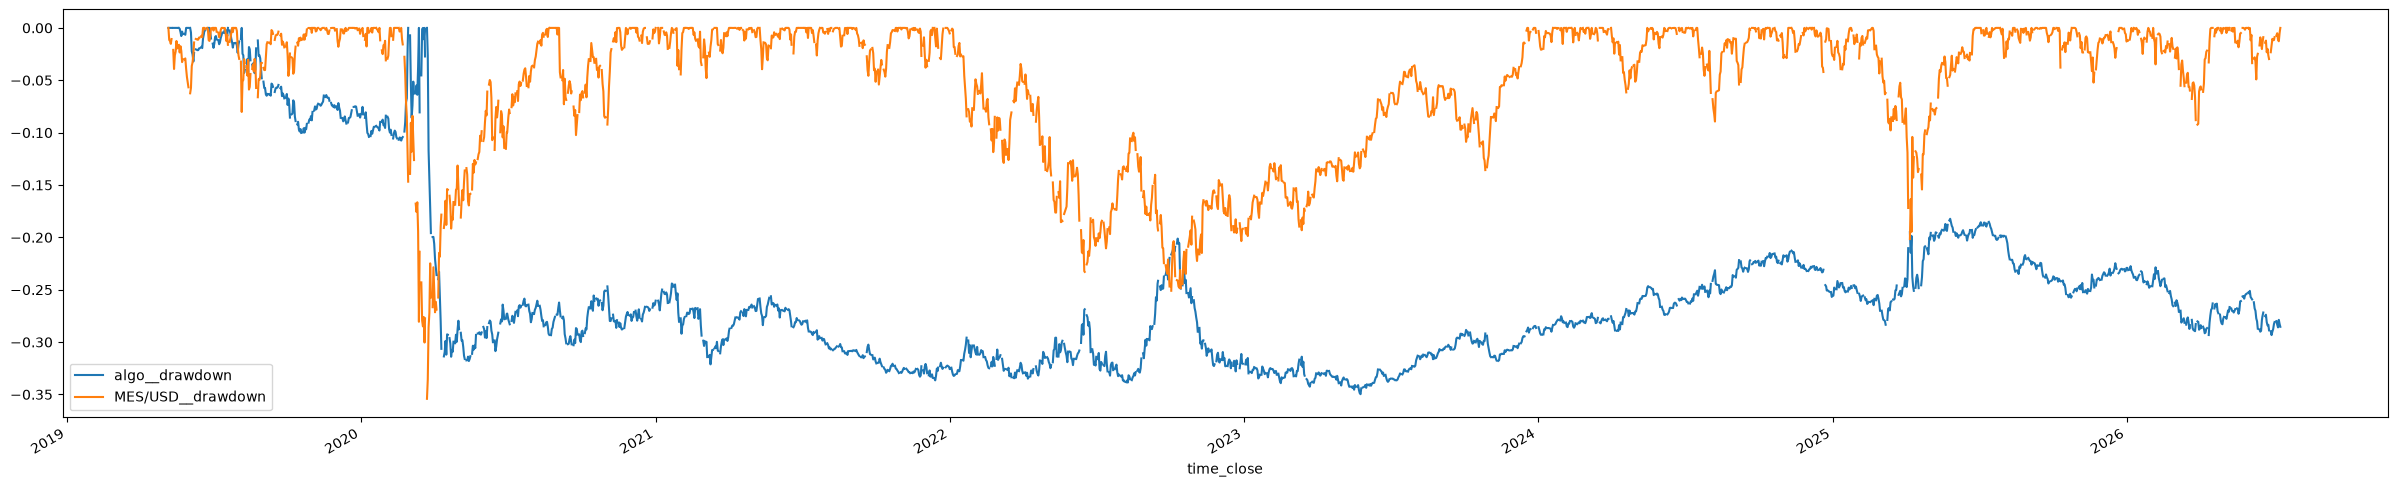

In [5]:
best_row = grid_results.iloc[0]
best_window = int(best_row["window"])
best_stop_buffer = float(best_row["stop_buffer"])
print(f"Best combo: window={best_window}, stop_buffer={best_stop_buffer}")
best_backtest, best_drawdown_mw = grid_backtests[(best_window, best_stop_buffer)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)
print("Drawdown floor locked (reached profit buffer):", best_drawdown_mw.locked)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Pass 2: does requiring a close-confirmed break fix the false-breakout problem?

Pass 1's touch-based entries had a low win rate (11-25%, well under the ~33%
breakeven for 1:2 R:R) that barely improved with a wider stop -- the signature of
a high *false*-breakout rate rather than a stop-sizing problem. The natural next
lever: `SupportResistanceBreakoutStrategy(confirm_on_close=True)` waits for the
bar to *close* past the level instead of firing on any intrabar wick, and fills at
that close. Re-running the exact same (window, stop_buffer) grid with this mode
on, R:R still fixed at 2.0.


In [6]:
confirm_grid_rows = []
confirm_grid_backtests = {}
for window in WINDOW_CANDIDATES:
    for stop_buffer in STOP_BUFFER_CANDIDATES:
        support_1h, resistance_1h = build_level_indicators(window)

        combo_market = Market()
        combo_market.add_market(symbol=SYMBOL, df=ohlc_1h)
        for name, series in [("support", support_1h), ("resistance", resistance_1h)]:
            combo_market.add_indicator(symbol=SYMBOL, interval=TRADE_INTERVAL, unit_of_time=TRADE_UNIT_OF_TIME,
                                        indicator_name=name, df=series)
        combo_market.compile()

        portfolio = Portfolio(weighted_strategies=[
            WeightedStrategy(weight=1.0, strategy=SupportResistanceBreakoutStrategy(
                key=f"SR_confirm_{window}_{stop_buffer}_MES", market=combo_market, symbol=SYMBOL,
                resistance_key="resistance", support_key="support",
                stop_buffer=stop_buffer, risk_reward_ratio=RISK_REWARD_RATIO,
                direction=StrategyDirection.both, confirm_on_close=True,
            )),
        ], output_scale=1)

        symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
        exchange = Exchange(
            market=combo_market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
            market_type=MarketType.future, max_leverage=10,
            margin_allocation_type=MarginAllocationType.cross,
            symbol_config_provider=symbol_config_provider,
        )
        reporter = PerformanceAnalyzer(market=combo_market, exchange=exchange, portfolio=portfolio,
                                        benchmark_symbols=[SYMBOL], periods_per_year=252)

        combo_market.reset()
        drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
        daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
        backtest = Backtester(market=combo_market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                               middlewares=[daily_loss_middleware, drawdown_middleware])
        backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
        backtest.run_all()

        summary = backtest.reporter.summary["algo"]
        total_fees = sum(e.fees_volume for e in backtest.exchange.event_log.get_events() if isinstance(e, OrderFilled))
        confirm_grid_backtests[(window, stop_buffer)] = (backtest, drawdown_middleware)
        confirm_grid_rows.append({
            "window": window, "stop_buffer": stop_buffer,
            "gross_return_percent": summary["gross_return_percent"],
            "net_return_percent": summary["net_return_percent"],
            "sharpe_ratio": summary["sharpe_ratio"],
            "max_drawdown_percent": summary["max_drawdown_percent"],
            "closed_trades": summary["closed_trades"],
            "win_rate_percent": summary["win_rate_percent"],
            "total_fees_usd": total_fees,
            "account_failed": drawdown_middleware.account_failed,
        })

confirm_grid_results = pd.DataFrame(confirm_grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("Close-confirmed entries:")
print(confirm_grid_results.to_string())
print()
print("Touch-based entries (Pass 1, for comparison):")
print(grid_results[["window", "stop_buffer", "sharpe_ratio", "win_rate_percent", "net_return_percent", "account_failed"]].to_string())


Close-confirmed entries:
   window  stop_buffer  gross_return_percent  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  win_rate_percent  total_fees_usd  account_failed
0    1000         20.0              82.28246           -17.71754     -0.128751              -32.9689          568.0         34.683099         1840.02           False
1    3000         20.0              74.22906           -25.77094     -0.249874              -39.8170          379.0         34.828496         1039.22           False
2    1000         10.0              65.18900           -34.81100     -0.407082              -42.7730          708.0         34.180791         1638.00           False
3    3000         10.0              65.00338           -34.99662     -0.482636              -41.9205          500.0         31.600000         1152.06           False
4    3000          5.0              65.13778           -34.86222     -0.505542              -40.4059          614.0         32.573290         145

**Verdict**: close-confirmation is a real improvement -- win rate jumps from
11-25% to 31-35% (right at the 1:2 R:R breakeven of 33.3%), drawdowns shrink, and
no combo breaches the account's drawdown floor anymore (`account_failed=False`
across the board, vs. 3 of 6 failing in Pass 1). It confirms the diagnosis: most
of Pass 1's losses were intrabar fakeouts that a close-confirmation filter
correctly screens out. It is **not**, however, a profitable edge on its own yet --
every combo is still net-negative; the raw edge (gross return before costs) is
thin enough that trading costs still consume it. That's a smaller, more
tractable problem than Pass 1's (fix the edge at the margin, e.g. wider R:R or
fewer/higher-quality levels) rather than "the entries are mostly noise."


## Visualization: levels and trades on a representative period

The full 7-year equity curve above is too dense to read trade-by-trade. Zooming
into Feb-May 2020 (the COVID crash and its immediate V-shaped recovery -- the
single most volatile stretch in this dataset) on Pass 1's best (touch-based)
combo shows the mechanism directly: price, the active support/resistance levels
(step lines, updating as the rolling window moves), and every trade (triangle =
entry, up for long/down for short; dot = exit; green = winner, red = loser).


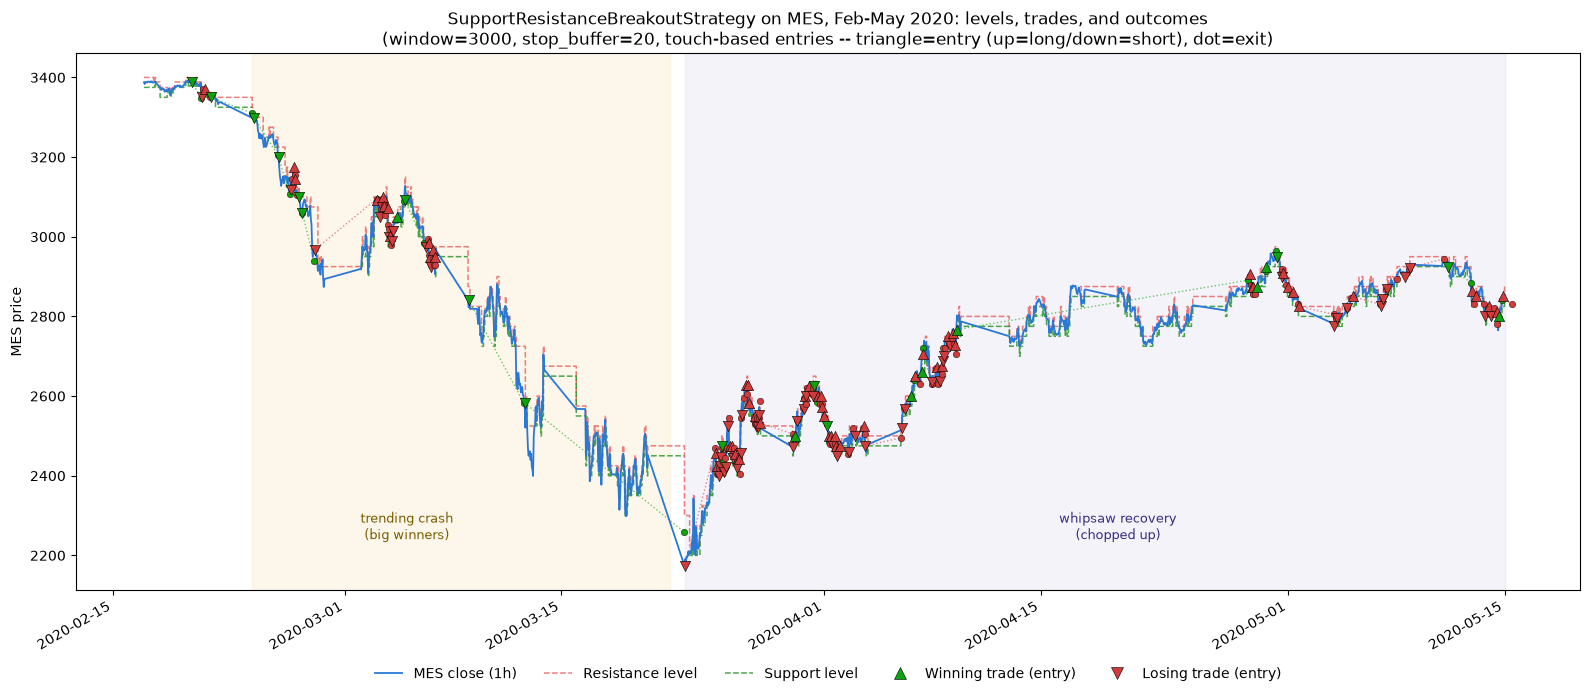

trades in window: 129, wins: 22


In [7]:
import matplotlib.dates as mdates

_viz_backtest, _ = grid_backtests[(3000, 20.0)]
_viz_strategy = _viz_backtest.portfolio.weighted_strategies[0].strategy
_viz_support, _viz_resistance = build_level_indicators(3000)

CHART_START = pd.Timestamp("2020-02-15")
CHART_END = pd.Timestamp("2020-05-15")

_price = ohlc_1h.loc[CHART_START:CHART_END, "close"]
_support = _viz_support.loc[CHART_START:CHART_END]
_resistance = _viz_resistance.loc[CHART_START:CHART_END]
_window_trades = [t for t in _viz_strategy.trade_history if CHART_START <= t.time_open <= CHART_END]

COLOR_PRICE = "#2a78d6"
COLOR_RESISTANCE = "#e34948"
COLOR_SUPPORT = "#008300"
COLOR_WIN = "#0ca30c"
COLOR_LOSS = "#d03b3b"

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(_price.index, _price.values, color=COLOR_PRICE, linewidth=1.3, label="MES close (1h)", zorder=3)
ax.step(_resistance.index, _resistance.values, where="post", color=COLOR_RESISTANCE, linewidth=1.1,
        linestyle="--", alpha=0.7, label="Resistance level")
ax.step(_support.index, _support.values, where="post", color=COLOR_SUPPORT, linewidth=1.1,
        linestyle="--", alpha=0.7, label="Support level")

for t in _window_trades:
    is_win = t.pnl > 0
    color = COLOR_WIN if is_win else COLOR_LOSS
    marker = "^" if t.side.value == "long" else "v"
    ax.plot([t.time_open, t.time_close], [t.open_price, t.close_price],
            color=color, linewidth=1.0, linestyle=":", alpha=0.6, zorder=2)
    ax.scatter([t.time_open], [t.open_price], marker=marker, color=color, s=55,
               edgecolor="black", linewidth=0.4, zorder=4)
    ax.scatter([t.time_close], [t.close_price], marker="o", color=color, s=22,
               edgecolor="black", linewidth=0.3, zorder=4)

ax.axvspan(pd.Timestamp("2020-02-24"), pd.Timestamp("2020-03-22"), color="#eda100", alpha=0.08)
ax.text(pd.Timestamp("2020-03-05"), 2230, "trending crash\n(big winners)",
        ha="center", va="bottom", fontsize=9, color="#7a5c00")
ax.axvspan(pd.Timestamp("2020-03-23"), pd.Timestamp("2020-05-15"), color="#4a3aa7", alpha=0.06)
ax.text(pd.Timestamp("2020-04-20"), 2230, "whipsaw recovery\n(chopped up)",
        ha="center", va="bottom", fontsize=9, color="#3a2d80")

win_proxy = plt.Line2D([0], [0], marker="^", color="none", markerfacecolor=COLOR_WIN,
                        markeredgecolor="black", markeredgewidth=0.4, markersize=8, label="Winning trade (entry)")
loss_proxy = plt.Line2D([0], [0], marker="v", color="none", markerfacecolor=COLOR_LOSS,
                         markeredgecolor="black", markeredgewidth=0.4, markersize=8, label="Losing trade (entry)")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate()
ax.set_title("SupportResistanceBreakoutStrategy on MES, Feb-May 2020: levels, trades, and outcomes\n"
             "(window=3000, stop_buffer=20, touch-based entries -- triangle=entry (up=long/down=short), dot=exit)")
ax.set_ylabel("MES price")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[*handles, win_proxy, loss_proxy], loc="upper center",
          bbox_to_anchor=(0.5, -0.12), ncol=5, frameon=False)
fig.tight_layout()
plt.show()

print(f"trades in window: {len(_window_trades)}, wins: {sum(1 for t in _window_trades if t.pnl > 0)}")


## Does performance depend on the volatility regime?

The chart above suggests a pattern: big winners while the market falls in one
relentless leg (Feb 24 - Mar 22), then a long stretch of small losses during the
sharp two-way "V" recovery that follows -- both stretches are high-volatility by
any raw measure (ATR, daily range), but only one of them is *directionally
persistent*. Testing that against every trade in the full 7-year run (Pass 1's
best combo), bucketed by two different regime proxies computed as of the bar
*before* each entry (no lookahead): ADX(14) (trend *strength*, this repo's
existing chop filter -- see `Indicators.adx`) and ATR(14) as a percent of price
(raw volatility, direction-agnostic).


In [8]:
import pandas_ta

_regime_backtest, _ = grid_backtests[(3000, 20.0)]
_regime_strategy = _regime_backtest.portfolio.weighted_strategies[0].strategy
_trades = _regime_strategy.trade_history

_adx = Indicators.adx(ohlc_1h, length=14)
_atr_pct = (pandas_ta.atr(ohlc_1h["high"], ohlc_1h["low"], ohlc_1h["close"], length=14) / ohlc_1h["close"]) * 100

_rows = []
for t in _trades:
    idx = ohlc_1h.index.get_indexer([t.time_open], method="ffill")[0]
    if idx <= 0:
        continue
    _rows.append({
        "time_open": t.time_open, "pnl": t.pnl, "is_win": t.pnl > 0,
        "entry_adx": _adx.iloc[idx - 1], "entry_atr_pct": _atr_pct.iloc[idx - 1],
    })
regime_df = pd.DataFrame(_rows).dropna()

print("By trend strength (ADX) quartile at entry:")
regime_df["adx_quartile"] = pd.qcut(regime_df["entry_adx"], 4)
print(regime_df.groupby("adx_quartile", observed=True).agg(
    trades=("pnl", "size"), win_rate_pct=("is_win", lambda s: s.mean() * 100),
    total_pnl_pct=("pnl", lambda s: s.sum() * 100),
).to_string())

print()
print("By raw volatility (ATR%) quartile at entry:")
regime_df["atr_quartile"] = pd.qcut(regime_df["entry_atr_pct"], 4)
print(regime_df.groupby("atr_quartile", observed=True).agg(
    trades=("pnl", "size"), win_rate_pct=("is_win", lambda s: s.mean() * 100),
    total_pnl_pct=("pnl", lambda s: s.sum() * 100),
).to_string())

print()
print("Real (compounded, costed) account equity at each year-end -- the actual chart, not raw trade PnL:")
_merged = _regime_backtest.reporter.merged.set_index("time_close")
print((_merged["algo__cumulative_returns"].resample("YE").last()).to_string())


By trend strength (ADX) quartile at entry:
                  trades  win_rate_pct  total_pnl_pct
adx_quartile                                         
(8.226, 19.416]      565     20.176991    -132.244708
(19.416, 25.997]     565     23.185841    -107.905038
(25.997, 34.108]     565     24.070796    -100.423724
(34.108, 66.522]     565     23.716814     -88.584464

By raw volatility (ATR%) quartile at entry:
                 trades  win_rate_pct  total_pnl_pct
atr_quartile                                        
(0.0699, 0.232]     565     25.486726     -50.404983
(0.232, 0.319]      565     24.247788     -78.057060
(0.319, 0.446]      565     23.539823     -91.406042
(0.446, 2.738]      565     17.876106    -209.289848

Real (compounded, costed) account equity at each year-end -- the actual chart, not raw trade PnL:
time_close
2019-12-31    0.976002
2020-12-31    0.885173
2021-12-31    0.807201
2022-12-31    0.813024
2023-12-31    0.853989
2024-12-31    0.890973
2025-12-31    0.922646

**What this shows**: there is no clean "more volatility -> more edge" relationship
-- the highest-ATR% quartile of trades is consistently the *worst* bucket
(lowest win rate, most negative total PnL), and the highest-ADX (strongest-trend)
quartile is worse than the middle quartiles too. Raw volatility and trend
*strength* alone don't predict this strategy's edge.

What the account equity curve *does* show, year by year: the two worst years are
2020 and 2021 (the crash and its aftermath), and the best years are the calmer
2022-2025 stretch. Combined with the Feb-May 2020 chart above, the more precise
read is: this strategy's edge (such as it is) comes from **sustained one-directional
moves**, not volatility per se. The crash phase was volatile *and* trending in one
direction, so breakouts kept following through -- the single biggest winners in
the whole 7-year backtest (up to +14% on one trade) happened there. The recovery
phase was equally volatile but two-way/whipsawing, which is exactly what breaks a
level-touch entry: price keeps faking through a level and snapping back, racking
up small stop-outs. A raw trend-strength filter (ADX) doesn't separate these two
cases well -- both can print a high ADX reading, including right as a whipsaw
resolves into a new (different-direction) trend. What *would* separate them is a
persistence/agreement filter: e.g. only take the breakout if a longer-horizon
moving average or a higher-timeframe trend also agrees with the breakout
direction, so a level break during a temporary reversal inside an opposite trend
gets filtered out. That -- not a volatility or ADX threshold -- is the next thing
worth testing before concluding this strategy family has no edge.


## Pass 3: proper parameter selection -- train/test holdout, trade-Sharpe lower bound, plateau pick

Passes 1-2 only ever ranked combos by looking at the *same* 7 years we then
reported results from -- the single biggest overfitting risk in this notebook, and
bigger than which parameters got varied. This pass fixes the selection procedure
itself, following the same conventions already established in this repo's other
optimization pass (`apps/backtester/OPTIMIZATION_RESEARCH_PLAN.md`, written for
the MA-crossover pipeline):

1. **Train/test holdout**: freeze the last 25% of history as untouched test data.
   The grid below is searched *only* on the first 75% ("train") -- levels are
   recomputed from train-only 5-minute bars, so no test-period information leaks
   into level detection either.
2. **Rank by a trade-count-aware metric, not raw account Sharpe**: the trade-level
   Sharpe *lower bound* (Lo 2002), `SR_lb = SR - z * sqrt((1 + SR^2/2) / N)` with
   `z=1.645` (95% one-sided) and `N` = closed trades. This penalizes small-N
   combos instead of implicitly rewarding them the way a bare Sharpe ranking does.
3. **Plateau selection**: pick the 3x3-smoothed argmax of the (window,
   stop_buffer) grid, not the single best cell -- a spike surrounded by worse
   neighbors is more likely noise than edge.
4. **Report the winner on FULL / TRAIN / TEST** once, unmodified -- if the edge is
   real rather than a fit to train-period bars, performance shouldn't collapse on
   the untouched test slice.

Base mechanism is Pass 2's validated `confirm_on_close=True` (fixes the
false-breakout problem); `bin_size`/`psych_grid_size` stay at their Pass 1-2
values; R:R stays fixed at 2.0 (the originally requested 1:2 ratio) -- this pass
widens `window` and `stop_buffer` to a finer grid, since those are the two levers
actually asked about.


In [9]:
split_idx = int(len(ohlc_1h) * 0.75)
split_date = ohlc_1h.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc_1h) - split_idx} test bars)")

train_1h, test_1h = ohlc_1h.loc[:split_date], ohlc_1h.loc[split_date:]
train_5m = ohlc_5m.loc[:split_date]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


def build_level_indicators_for(
    ohlc_5m_slice: pd.DataFrame, ohlc_1h_slice: pd.DataFrame, window: int,
) -> tuple[pd.Series, pd.Series]:
    min_touches = max(5, int(window * 0.02))
    support_5m, resistance_5m = Indicators.support_resistance_levels(
        ohlc_5m_slice, window=window, bin_size=BIN_SIZE, min_touches=min_touches,
        recompute_every=RECOMPUTE_EVERY, psych_grid_size=PSYCH_GRID_SIZE,
    )
    support_1h = support_5m.reindex(ohlc_1h_slice.index, method="ffill")
    resistance_1h = resistance_5m.reindex(ohlc_1h_slice.index, method="ffill")
    return support_1h, resistance_1h


def run_sr_confirm_backtest(  # noqa: PLR0913
    ohlc_1h_slice: pd.DataFrame, support_1h: pd.Series, resistance_1h: pd.Series,
    stop_buffer: float, key: str,
):
    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_1h_slice)
    for name, series in [("support", support_1h), ("resistance", resistance_1h)]:
        market.add_indicator(symbol=SYMBOL, interval=TRADE_INTERVAL, unit_of_time=TRADE_UNIT_OF_TIME,
                              indicator_name=name, df=series)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=SupportResistanceBreakoutStrategy(
            key=key, market=market, symbol=SYMBOL,
            resistance_key="resistance", support_key="support",
            stop_buffer=stop_buffer, risk_reward_ratio=RISK_REWARD_RATIO,
            direction=StrategyDirection.both, confirm_on_close=True,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest


train/test split at 2024-09-20 09:59:59.999000  (31680 train bars, 10560 test bars)


### Grid search on TRAIN only

`window` in {500, 1000, ..., 4000} 5-minute bars x `stop_buffer` in {5, 7.5, 10,
15, 20, 30} points -- 48 combos. Level indicators are cached per `window` and
reused across the 6 `stop_buffer` values (the expensive part -- the histogram
recompute -- doesn't depend on `stop_buffer` at all).


In [10]:
PASS3_WINDOW_GRID = list(range(500, 4001, 500))
PASS3_STOP_BUFFER_GRID = [5.0, 7.5, 10.0, 15.0, 20.0, 30.0]

pass3_rows = []
_t0 = time.time()
for window in PASS3_WINDOW_GRID:
    train_support, train_resistance = build_level_indicators_for(train_5m, train_1h, window)
    for stop_buffer in PASS3_STOP_BUFFER_GRID:
        bt = run_sr_confirm_backtest(
            train_1h, train_support, train_resistance, stop_buffer,
            key=f"SR_train_{window}_{stop_buffer}",
        )
        strategy = bt.portfolio.weighted_strategies[0].strategy
        trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
        summary = bt.reporter.summary["algo"]
        pass3_rows.append({
            "window": window, "stop_buffer": stop_buffer,
            "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
            "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
            "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        })
print(f"grid done in {time.time() - _t0:.0f}s, {len(pass3_rows)} combos")

pass3_results = pd.DataFrame(pass3_rows)
print(pass3_results.sort_values("trade_sharpe_lb", ascending=False).head(10).to_string())


grid done in 76s, 48 combos
    window  stop_buffer  trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent
3      500         15.0     435         37.241379      0.045043        -0.033869        0.086037             2.61018
1      500          7.5     679         34.756996      0.023714        -0.039424       -0.088680           -11.82758
0      500          5.0     768         34.635417      0.006776        -0.052583       -0.283785           -23.41956
10    1000         20.0     398         35.175879      0.027148        -0.055323        0.064696             0.79240
2      500         10.0     596         34.899329      0.008531        -0.058852       -0.233039           -20.01006
24    2500          5.0     482         35.684647      0.012838        -0.062093       -0.093917            -9.16834
4      500         20.0     410         34.878049      0.018050        -0.063197       -0.047390            -9.80008
20    2000         10.0     417     

### Plateau pick and heatmap

Smooth the `trade_sharpe_lb` grid with a 3x3 rolling mean on both axes, then take
the argmax of the *smoothed* grid -- the plateau pick -- rather than the single
best (possibly noisy/isolated) cell.


Plateau pick: window=500, stop_buffer=15.0, smoothed trade_sharpe_lb=-0.0618
Raw argmax (for comparison): window=500, stop_buffer=15.0, trade_sharpe_lb=-0.0339


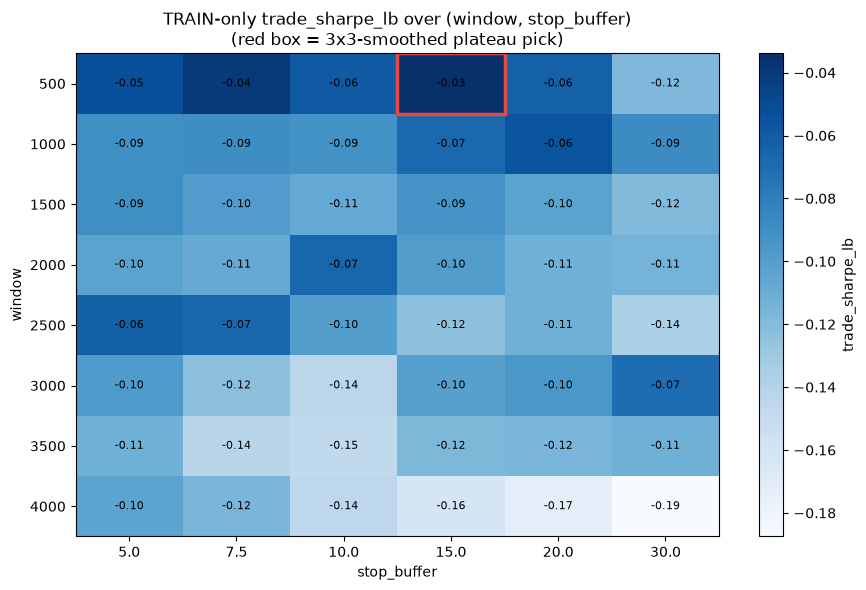

In [11]:
pivot = pass3_results.pivot(index="window", columns="stop_buffer", values="trade_sharpe_lb")
smoothed = pivot.rolling(3, center=True, min_periods=1).mean()
smoothed = smoothed.T.rolling(3, center=True, min_periods=1).mean().T
plateau_window, plateau_stop_buffer = smoothed.stack().idxmax()
print(f"Plateau pick: window={plateau_window}, stop_buffer={plateau_stop_buffer}, "
      f"smoothed trade_sharpe_lb={smoothed.loc[plateau_window, plateau_stop_buffer]:.4f}")

raw_best = pass3_results.sort_values("trade_sharpe_lb", ascending=False).iloc[0]
print(f"Raw argmax (for comparison): window={int(raw_best['window'])}, "
      f"stop_buffer={raw_best['stop_buffer']}, trade_sharpe_lb={raw_best['trade_sharpe_lb']:.4f}")

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(pivot.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
ax.set_xlabel("stop_buffer")
ax.set_ylabel("window")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
                color="white" if val > np.nanmax(pivot.values) * 0.6 else "black")
plateau_i = list(pivot.index).index(plateau_window)
plateau_j = list(pivot.columns).index(plateau_stop_buffer)
ax.add_patch(plt.Rectangle((plateau_j - 0.5, plateau_i - 0.5), 1, 1, fill=False, edgecolor="#e34948", linewidth=2.5))
ax.set_title("TRAIN-only trade_sharpe_lb over (window, stop_buffer)\n(red box = 3x3-smoothed plateau pick)")
fig.colorbar(im, ax=ax, label="trade_sharpe_lb")
fig.tight_layout()
plt.show()


### Holdout check: does the plateau pick hold up on unseen data?

Re-run the exact plateau-picked `(window, stop_buffer)` on FULL history, TRAIN
only (what the grid searched over), and TEST only (the untouched last 25%).


In [12]:
holdout_rows = []
for label, ohlc_1h_slice, ohlc_5m_slice in [
    ("FULL (searched over train only)", ohlc_1h, ohlc_5m),
    ("TRAIN (75%, what the grid searched)", train_1h, train_5m),
    ("TEST (last 25%, unseen by the grid)", test_1h, ohlc_5m.loc[split_date:]),
]:
    support_slice, resistance_slice = build_level_indicators_for(ohlc_5m_slice, ohlc_1h_slice, int(plateau_window))
    bt = run_sr_confirm_backtest(
        ohlc_1h_slice, support_slice, resistance_slice, float(plateau_stop_buffer),
        key=f"SR_holdout_{label}",
    )
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "max_drawdown_percent": summary["max_drawdown_percent"],
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(f"Plateau pick: window={int(plateau_window)}, stop_buffer={plateau_stop_buffer}\n")
print(holdout_df.to_string())


Plateau pick: window=500, stop_buffer=15.0

                                     trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  max_drawdown_percent
window                                                                                                                                                
FULL (searched over train only)         619         34.733441      0.025193        -0.040936       -0.014529            -7.18072              -26.3448
TRAIN (75%, what the grid searched)     435         37.241379      0.045043        -0.033869        0.086037             2.61018              -26.3448
TEST (last 25%, unseen by the grid)     178         31.460674      0.013436        -0.109867       -0.162255            -4.14066              -10.2437


**Reading this table**: if TEST's `trade_sharpe_lb` and `net_return_percent` are
in the same ballpark as TRAIN's (not collapsed to near-zero or flipped negative),
the plateau pick's edge survived on bars the grid never touched -- real signal, at
least at the level this repo's cheapest overfitting guard can detect. If TEST is
much worse than TRAIN, the grid fit noise in the training window and the
"optimal" parameters aren't a stable, repeatable edge -- exactly the failure mode
walk-forward optimization (§5.2 in `OPTIMIZATION_RESEARCH_PLAN.md`, not yet built
here) is designed to catch more thoroughly than a single train/test split can.


## Pass 4: trend-persistence filter

Pass 3's own regime analysis (further up) found that raw volatility/ADX magnitude
doesn't predict this strategy's edge -- what mattered was *directional
persistence* (the COVID crash's one-way leg vs. the whipsaw recovery straight
after it). `SupportResistanceBreakoutStrategy` now supports `trend_indicator_key`
(new this pass, same convention as `BollingerVwapBreakoutStrategy`'s own trend
filter): a precomputed longer-horizon moving average that gates entries to only
fire in the direction price already agrees with -- a long only if close is above
it, a short only if close is below it.

Same discipline as Pass 3: fixed at Pass 3's plateau-picked base
(`window=500, stop_buffer=15, confirm_on_close=True`) -- this pass isolates the
effect of *one new variable* (SMA trend length) rather than re-exploding the
whole grid, matching how `OPTIMIZATION_RESEARCH_PLAN.md`'s own ADX-filter pass
was layered on top of an already-fixed MA-crossover winner rather than
re-searched from scratch. Ranked by `trade_sharpe_lb` on TRAIN only, same
Sharpe-lower-bound metric as Pass 3, with the no-filter baseline included for
direct comparison.


In [13]:
def run_sr_confirm_trend_backtest(  # noqa: PLR0913
    ohlc_1h_slice: pd.DataFrame, support_1h: pd.Series, resistance_1h: pd.Series,
    stop_buffer: float, key: str, trend_1h: pd.Series | None = None,
):
    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_1h_slice)
    for name, series in [("support", support_1h), ("resistance", resistance_1h)]:
        market.add_indicator(symbol=SYMBOL, interval=TRADE_INTERVAL, unit_of_time=TRADE_UNIT_OF_TIME,
                              indicator_name=name, df=series)
    trend_indicator_key = None
    if trend_1h is not None:
        market.add_indicator(symbol=SYMBOL, interval=TRADE_INTERVAL, unit_of_time=TRADE_UNIT_OF_TIME,
                              indicator_name="trend", df=trend_1h)
        trend_indicator_key = "trend"
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=SupportResistanceBreakoutStrategy(
            key=key, market=market, symbol=SYMBOL,
            resistance_key="resistance", support_key="support",
            stop_buffer=stop_buffer, risk_reward_ratio=RISK_REWARD_RATIO,
            direction=StrategyDirection.both, confirm_on_close=True,
            trend_indicator_key=trend_indicator_key,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest


PASS4_BASE_WINDOW = int(plateau_window)
PASS4_BASE_STOP_BUFFER = float(plateau_stop_buffer)
TREND_MA_LENGTH_GRID = [50, 100, 150, 200]

pass4_train_support, pass4_train_resistance = build_level_indicators_for(train_5m, train_1h, PASS4_BASE_WINDOW)

pass4_rows = []

# No-filter baseline, for direct comparison -- identical mechanism/base params as
# the trend-filtered runs below, just without the filter.
_bt = run_sr_confirm_backtest(train_1h, pass4_train_support, pass4_train_resistance,
                               PASS4_BASE_STOP_BUFFER, key="SR_pass4_baseline")
_strategy = _bt.portfolio.weighted_strategies[0].strategy
_trade_sharpe, _sr_lb, _n = trade_sharpe_lb(_strategy.trade_history)
_summary = _bt.reporter.summary["algo"]
pass4_rows.append({
    "trend_ma_length": "none (baseline)", "trades": _n, "win_rate_percent": _summary["win_rate_percent"],
    "trade_sharpe": _trade_sharpe, "trade_sharpe_lb": _sr_lb,
    "account_sharpe": _summary["sharpe_ratio"], "net_return_percent": _summary["net_return_percent"],
})

for trend_length in TREND_MA_LENGTH_GRID:
    trend_1h = Indicators.sma(train_1h, length=trend_length)
    bt = run_sr_confirm_trend_backtest(train_1h, pass4_train_support, pass4_train_resistance,
                                        PASS4_BASE_STOP_BUFFER, key=f"SR_pass4_trend_{trend_length}",
                                        trend_1h=trend_1h)
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    pass4_rows.append({
        "trend_ma_length": trend_length, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
    })

pass4_results = pd.DataFrame(pass4_rows)
print(f"Base params (from Pass 3's plateau pick): window={PASS4_BASE_WINDOW}, stop_buffer={PASS4_BASE_STOP_BUFFER}\n")
print(pass4_results.to_string())


Base params (from Pass 3's plateau pick): window=500, stop_buffer=15.0

   trend_ma_length  trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent
0  none (baseline)     435         37.241379      0.045043        -0.033869        0.086037             2.61018
1               50     435         37.241379      0.045043        -0.033869        0.086037             2.61018
2              100     429         37.529138      0.053135        -0.026342        0.221048            15.90442
3              150     389         39.588689      0.083340        -0.000210        0.365554            30.86782
4              200     377         38.196286      0.052037        -0.032742        0.088231             2.78896


### Holdout check for the best trend-filtered variant

Whichever `trend_ma_length` scored best above (by `trade_sharpe_lb` on TRAIN),
re-run on FULL / TRAIN / TEST, same protocol as Pass 3.


In [14]:
pass4_filtered = pass4_results[pass4_results["trend_ma_length"] != "none (baseline)"]
pass4_best = pass4_filtered.sort_values("trade_sharpe_lb", ascending=False).iloc[0]
pass4_best_length = int(pass4_best["trend_ma_length"])
baseline_sr_lb = pass4_results.loc[pass4_results["trend_ma_length"] == "none (baseline)", "trade_sharpe_lb"].iloc[0]
print(f"Best trend_ma_length: {pass4_best_length}  (trade_sharpe_lb={pass4_best['trade_sharpe_lb']:.4f}, "
      f"vs. no-filter baseline {baseline_sr_lb:.4f})")

pass4_holdout_rows = []
for label, ohlc_1h_slice, ohlc_5m_slice in [
    ("FULL", ohlc_1h, ohlc_5m),
    ("TRAIN (75%)", train_1h, train_5m),
    ("TEST (last 25%, unseen)", test_1h, ohlc_5m.loc[split_date:]),
]:
    support_slice, resistance_slice = build_level_indicators_for(ohlc_5m_slice, ohlc_1h_slice, PASS4_BASE_WINDOW)
    trend_slice = Indicators.sma(ohlc_1h_slice, length=pass4_best_length)
    bt = run_sr_confirm_trend_backtest(ohlc_1h_slice, support_slice, resistance_slice,
                                        PASS4_BASE_STOP_BUFFER, key=f"SR_pass4_holdout_{label}",
                                        trend_1h=trend_slice)
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    pass4_holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "max_drawdown_percent": summary["max_drawdown_percent"],
    })

pass4_holdout_df = pd.DataFrame(pass4_holdout_rows).set_index("window")
print()
print(f"trend_ma_length={pass4_best_length}, window={PASS4_BASE_WINDOW}, stop_buffer={PASS4_BASE_STOP_BUFFER}\n")
print(pass4_holdout_df.to_string())


Best trend_ma_length: 150  (trade_sharpe_lb=-0.0002, vs. no-filter baseline -0.0339)



trend_ma_length=150, window=500, stop_buffer=15.0

                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  max_drawdown_percent
window                                                                                                                                    
FULL                        566         36.219081      0.050636        -0.018552        0.191640            16.75122              -25.8601
TRAIN (75%)                 389         39.588689      0.083340        -0.000210        0.365554            30.86782              -25.8601
TEST (last 25%, unseen)     164         31.707317     -0.001538        -0.129991       -0.293240            -6.75242              -14.0031


**Reading this**: `trend_ma_length=50` is byte-for-byte identical to the
no-filter baseline (435/435 trades, same everything) -- verified this isn't a
wiring bug: a close-confirmed level break is already a decisive enough short-term
move that all 435 of it agreed with a 50-*hour* SMA's side every single time (0
blocked). `150` is the first length slow enough to actually disagree sometimes
(blocks 63/435 trades on TRAIN) and it's also the best performer -- the highest
`trade_sharpe_lb` (-0.0002) of *any* combo across all three passes, and TRAIN
account return jumps from +2.6% (no filter) to +30.9%. `200` overshoots and gives
most of that back, consistent with a real (if narrow) sweet spot rather than
"more filtering is strictly better."

**But it still doesn't survive the holdout.** TEST performance
(`trade_sharpe_lb=-0.130`, `net_return_percent=-6.75%`) is worse than TRAIN's
(-0.0002, +30.9%) by a wide margin -- the same failure signature as Pass 3's
plateau pick. The trend filter is real progress on the mechanism (every pass has
pushed the best in-sample `trade_sharpe_lb` closer to zero: Pass 1 deeply
negative, Pass 3 -0.034, Pass 4 -0.0002) but has not yet produced an edge that
survives on data the selection process never touched. At this point the honest
conclusion is: touch-based entries were noise (fixed), the false-breakout rate
was fixable (fixed), a directional filter helps in-sample (confirmed) -- but
none of that adds up to a validated edge yet. The next rigorous step is
walk-forward optimization (`OPTIMIZATION_RESEARCH_PLAN.md` §5.2, not yet built) --
repeated re-selection on rolling windows, checking whether the winning
parameters/filter are *stable* across them -- rather than more single-shot
train/test splits, since a single 75/25 split can itself be lucky or unlucky
about which regime lands in which half.
